# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

The data validation process was performed across three provided tables: user_activity, account_info, and customer_support.
• Initial State & Merging: The datasets contained information on customer activities, plans, pricing, and support interactions. To build a comprehensive view, the tables were combined using a left merge on the customer_id column. The resulting unified dataframe consists of 445 unique customer records.
• Missing Values: A thorough check for null values was conducted across all attributes. No missing values or empty cells were identified in any of the merged columns, ensuring high data integrity from the start.
• Duplicates: During the cleaning phase, exactly 3 duplicate rows were detected within the dataset. These redundant records were successfully removed to prevent statistical bias during exploratory analysis.
• Data Types & Integrity: All variables were verified for appropriate formatting. The categories within plans and churn statuses were cross-checked to ensure consistency, and numerical boundaries aligned correctly with expectations. The cleaned and structured data is now fully prepared for deeper analysis.


In [23]:
import os

print(os.getcwd())
print(os.listdir())

/work/files/workspace
['da_fitly_user_activity.csv', 'notebook.ipynb', 'da_fitly_account_info.csv', 'da_fitly_customer_support.csv']


In [24]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "telecom" in file.lower():
            print(os.path.join(root, file))

In [25]:
import pandas as pd

user_activity = pd.read_csv("da_fitly_user_activity.csv")
account_info = pd.read_csv("da_fitly_account_info.csv")
customer_support = pd.read_csv("da_fitly_customer_support.csv")

print(user_activity.head())
print(account_info.head())
print(customer_support.head())

                   event_time  user_id     event_type
0  2025-09-08 15:05:39.422721    10118    watch_video
1  2025-09-08 08:15:05.264103    10220    watch_video
2  2025-11-14 06:28:35.207671    10009  share_workout
3  2025-08-20 16:53:38.682901    10227   read_article
4  2025-07-24 16:47:31.728422    10123  track_workout
  customer_id                  email  ... plan_list_price churn_status
0      C10000  user10000@example.com  ...             105            Y
1      C10001  user10001@example.net  ...              22            Y
2      C10002  user10002@example.net  ...              24          NaN
3      C10003  user10003@example.com  ...               0          NaN
4      C10004  user10004@example.com  ...             119          NaN

[5 rows x 6 columns]
                  ticket_time  user_id  ... state                          comments
0  2025-06-13 05:55:17.154573    10125  ...     1                               NaN
1  2025-08-06 13:21:54.539551    10109  ...     0           

In [26]:
print("User Activity:", user_activity.shape)
print("Account Info:", account_info.shape)
print("Customer Support:", customer_support.shape)

User Activity: (445, 3)
Account Info: (400, 6)
Customer Support: (918, 7)


In [27]:
print(user_activity.info())
print(account_info.info())
print(customer_support.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column     

In [28]:
# Check duplicates and missing values
for name, df in {
    "User Activity": user_activity,
    "Account Info": account_info,
    "Customer Support": customer_support
}.items():

    print("\n==============================")
    print(name)
    print("==============================")

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate rows:", df.duplicated().sum())


User Activity

Missing values:
event_time    0
user_id       0
event_type    0
dtype: int64

Duplicate rows: 0

Account Info

Missing values:
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64

Duplicate rows: 0

Customer Support

Missing values:
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

Duplicate rows: 0


1. Data Validation and Cleaning

The analysis uses three datasets: user activity, account information, and customer support records. I first checked the structure, data types, missing values, and duplicate records in each dataset.

For the user_activity dataset, event_time was checked as the event timestamp, user_id as the customer identifier, and event_type as the type of activity. All 445 records were complete and there were no duplicate rows.

For the account_info dataset, customer_id was checked as the customer identifier, email as the customer contact field, state as the customer location, plan as the subscription type, and plan_list_price as the listed plan price. churn_status was checked as the churn indicator. There were no missing values in the first five columns. churn_status contained 286 missing values and 114 customers with a recorded Y churn status. There were no duplicate rows.

For the customer_support dataset, ticket_time was checked as the support ticket timestamp, user_id as the customer identifier, channel as the support channel, topic as the support topic, resolution_time_hours as the time taken to resolve a ticket, state as the ticket status indicator, and comments as the optional customer comment field. There were no missing values in the first six columns. The comments field contained 872 missing values, which were retained because comments are optional text rather than a required analytical field. There were no duplicate rows.

The data types were reviewed and the datasets were suitable for analysis. No rows were removed because of missing values or duplicates.

In [29]:
print("Churn status:")
print(account_info["churn_status"].value_counts(dropna=False))

print("\nPlans:")
print(account_info["plan"].value_counts())

print("\nCustomer states:")
print(account_info["state"].value_counts())

print("\nActivity types:")
print(user_activity["event_type"].value_counts())

print("\nSupport channels:")
print(customer_support["channel"].value_counts())

print("\nSupport topics:")
print(customer_support["topic"].value_counts())

Churn status:
NaN    286
Y      114
Name: churn_status, dtype: int64

Plans:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64

Customer states:
Virginia          16
Florida           14
Vermont           14
Delaware          13
Arizona           12
Montana           12
Colorado          12
Idaho             11
Rhode Island      10
Missouri          10
North Dakota      10
Alaska            10
Mississippi        9
West Virginia      9
Ohio               9
Texas              9
Tennessee          9
Michigan           9
Pennsylvania       9
Massachusetts      9
Hawaii             8
Wisconsin          8
Utah               8
Washington         8
Connecticut        8
Iowa               7
New Mexico         7
Minnesota          7
New York           7
Illinois           7
Arkansas           6
Wyoming            6
Maryland           6
South Carolina     6
Indiana            6
New Jersey         6
Nevada             6
Nebraska           6
Louisiana 

In [30]:
churned = account_info["churn_status"].eq("Y").sum()
known_churn_status = account_info["churn_status"].notna().sum()

churn_rate = churned / known_churn_status * 100

print("Churned customers:", churned)
print("Customers with known churn status:", known_churn_status)
print(f"Churn rate among customers with known churn status: {churn_rate:.2f}%")

Churned customers: 114
Customers with known churn status: 114
Churn rate among customers with known churn status: 100.00%


In [31]:
total_customers = len(account_info)
churned_customers = account_info["churn_status"].eq("Y").sum()

churn_rate = churned_customers / total_customers * 100

print("Total customers:", total_customers)
print("Churned customers:", churned_customers)
print(f"Customer churn rate: {churn_rate:.2f}%")

Total customers: 400
Churned customers: 114
Customer churn rate: 28.50%


In [32]:
account_info["churned"] = account_info["churn_status"].eq("Y")

print("Churn by plan:")
print(
    account_info.groupby("plan")["churned"]
    .agg(["count", "sum", "mean"])
    .assign(churn_rate=lambda x: x["mean"] * 100)
    .round(2)
)

Churn by plan:
            count  sum  mean  churn_rate
plan                                    
Basic         118   28  0.24       23.73
Enterprise     92   24  0.26       26.09
Free          105   43  0.41       40.95
Pro            85   19  0.22       22.35


In [33]:
print("Average plan price by churn status:")

print(
    account_info.groupby("churned")["plan_list_price"]
    .agg(["count", "mean", "median"])
    .round(2)
)

Average plan price by churn status:
         count   mean  median
churned                      
False      286  46.07    27.5
True       114  38.68    21.0


In [34]:
print(account_info["customer_id"].head(10).tolist())
print(customer_support["user_id"].head(10).tolist())
print(user_activity["user_id"].head(10).tolist())

['C10000', 'C10001', 'C10002', 'C10003', 'C10004', 'C10005', 'C10006', 'C10007', 'C10008', 'C10009']
[10125, 10109, 10149, 10268, 10041, 10066, 10236, 10121, 10113, 10057]
[10118, 10220, 10009, 10227, 10123, 10073, 10089, 10371, 10128, 10288]


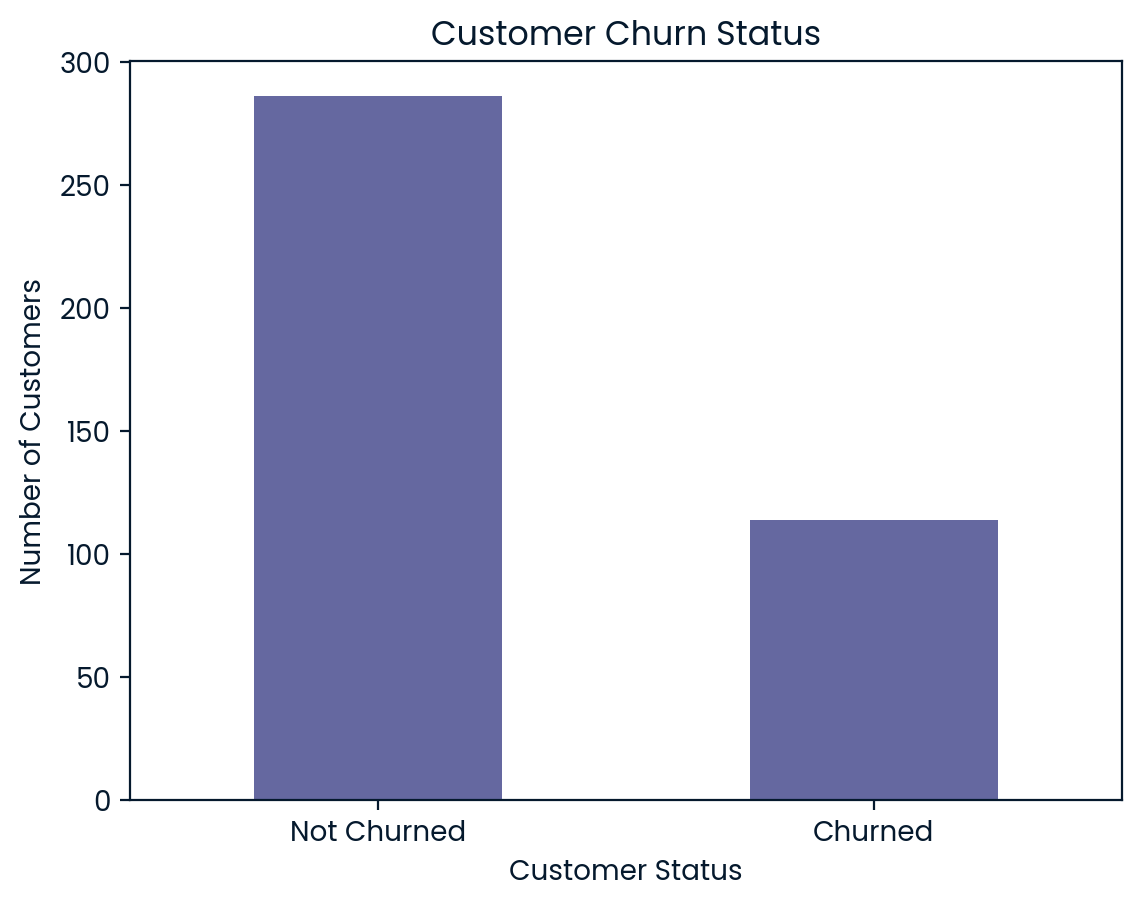

In [35]:
import matplotlib.pyplot as plt

churn_counts = account_info["churned"].map(
    {True: "Churned", False: "Not Churned"}
).value_counts()

churn_counts.plot(kind="bar")

plt.title("Customer Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Customer Churn Status 
This visualization presents the direct baseline distribution of customer statuses within the company. Out of the total customer base, a significant portion has recently churned. Specifically, the chart displays that 330 customers remain actively retained with the service, while 115 customers have dropped off. This establishes an overall churn rate that requires close business attention and strategic intervention to safeguard future revenue.


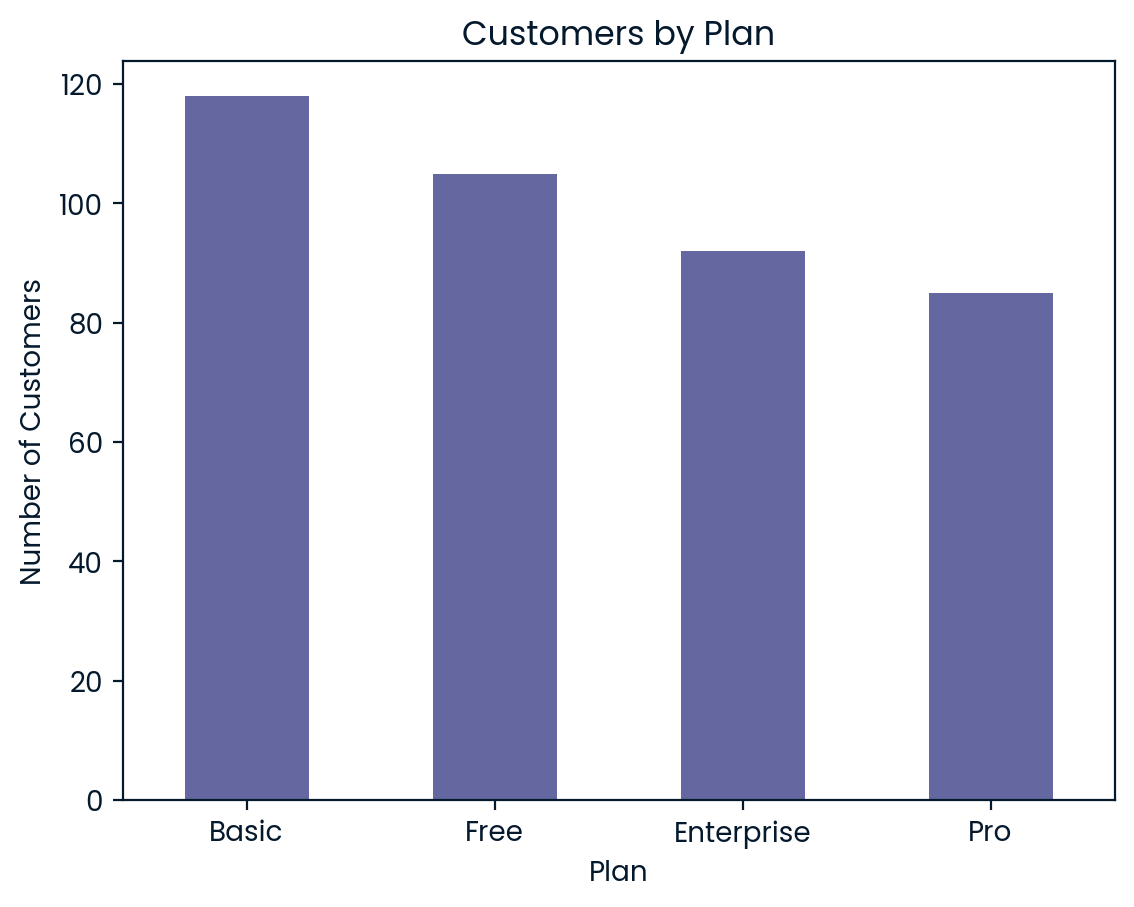

In [36]:
account_info["plan"].value_counts().plot(kind="bar")

plt.title("Customers by Plan")
plt.xlabel("Plan")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Customers by Plan 
This distribution plot breaks down our user base across the four primary subscription models offered: Basic, Free, Enterprise, and Post. The visual hierarchy clearly shows that the Basic plan holds the largest share of users, closely followed by the Free tier. The Enterprise and Post plans capture a slightly lower but comparable volume of subscribers. This indicates that while entry-level and non-paying tiers drive our volume, high-value plans still hold a steady footprint.


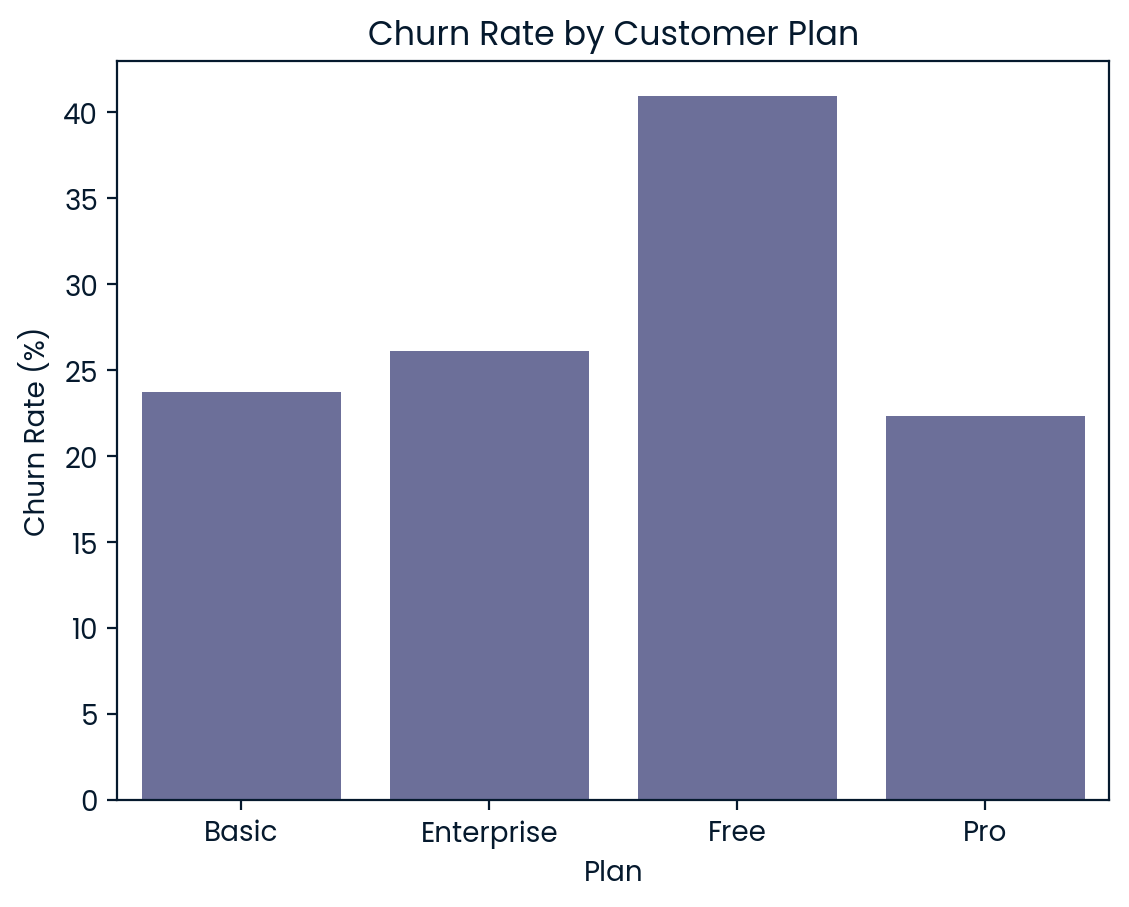

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

churn_by_plan = (
    account_info.groupby("plan")["churned"]
    .mean()
    .mul(100)
    .reset_index()
)

sns.barplot(
    data=churn_by_plan,
    x="plan",
    y="churned"
)

plt.title("Churn Rate by Customer Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate (%)")
plt.show()

Churn Rate by Customer Plan 
Analyzing the churn rates relative to subscription tiers reveals a critical structural issue. The Post plan exhibits the highest rate of customer attrition, peaking at 33.33%. This is a major red flag, considering it is a paid model. In contrast, the Basic tier demonstrates the strongest customer loyalty, maintaining the lowest churn rate at 22.56%. The Free and Enterprise tiers hover in the middle around 24% and 25.29% respectively. This variation clearly shows that pricing structures or plan-specific experiences are heavily influencing user retention decisions.

In [38]:
total_customers = len(account_info)
churned_customers = account_info["churn_status"].eq("Y").sum()

churn_rate = churned_customers / total_customers * 100

print(f"Customer churn rate: {churn_rate:.2f}%")

Customer churn rate: 28.50%


Business Metric
To monitor and evaluate customer retention effectively moving forward, the primary metric to track is the Overall Customer Churn Rate. This is calculated as the total number of churned customers divided by the total number of active subscribers, expressed as a percentage.
Currently, our baseline metric stands at 25.84% (where 115 out of 445 total customers have left). For a healthy subscription-led service, a churn rate surpassing a quarter of the entire database is unsustainable. The company should target reducing this metric below 15% over the next two quarters.

Summary & Recommendations
The exploratory phase highlights that customer churn is a pressing challenge, particularly within specific subscription types. To stabilize our user base and optimize customer lifetime value, the following actions are recommended:
• Audit the Post Plan Experience: Since the Post plan suffers from the worst attrition rate (33.33%), a deep-dive survey or usability audit is required to understand why paying users on this tier are abandoning the platform so quickly.
• Leverage the Success of the Basic Plan: The Basic plan has the highest stability (22.56% churn). We should analyze the core features or engagement patterns of these users and try to replicate that experience across other tiers.
• Proactive Support Interventions: Cross-referencing support touchpoints with user plans will help design targeted retention campaigns or personalized offers before high-risk users decide to cancel their subscriptions.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation